## Importación de Librerias


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, lfilter, filtfilt
from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis
import pywt
from typing import List, Tuple, Dict, Any
import os
import glob

## Algoritmo de extracción de caracteristicas
### 1 Observador
El primer observador denonimado observador puesto que presenta la capacidad de analizar la señal de entrada para identificar en que instante de tiempo ocurre una caida de tension por debajo del 90% de su valor rms.

Este observador utiliza la envolvente de la transformada hilbert, con el objetivo de poder realizar una mascara para comparar el dato de la mascara un umbral definido mediante el valor rms de la señal

### 2 Observador
El segundo observador es capaz de identificar en que instante de tiempo ocurre una transición de la señal de entrada mediante la transformada wavelet estacionaria (SWT), para poder identificar en que tiempo ocurre se utiliza el umbral de donoho

### Tener en cuenta
La Funcion detectar contempla ambos observadores llamados triggers, la funcion rms permite  extraer la mediana del valor rms que se calcula por cada ciclo. La funcion unir intervalos permite unir la información extraida por cada uno de los observadores para unificar la respuesta.


In [7]:
# --- FUNCIÓN AUXILIAR PARA FUSIONAR EVENTOS ---
# Se incluye para que el código sea completamente funcional y una eventos diferentes de ambos triggers.
def unir_intervalos(intervalos: List[Tuple[int, int]], margen_muestras: int) -> List[Tuple[int, int]]:
    """
    Fusiona intervalos solapados o adyacentes.
    """
    if not intervalos:
        return []
    
    # Ordenar intervalos por su punto de inicio
    intervalos.sort(key=lambda x: x[0])
    
    union = [intervalos[0]]
    
    for actual_inicio, actual_final in intervalos[1:]:
        ultimo_inicio, ultimo_final = union[-1]
        
        # Si hay solapamiento o son contiguos, se fusionan
        if actual_inicio <= (ultimo_final + margen_muestras):
            union[-1] = (ultimo_inicio, max(ultimo_final, actual_final))
        else:
            union.append((actual_inicio, actual_final))
            
    return union

# --- FUNCIÓN DE CÁLCULO DEL RMS NOMINAL ---
def rms_nominal(signal: np.ndarray, fs: int) -> float:
    """
    Calcula el RMS nominal de la señal.
    """
    muestras_por_ciclo = fs // 60  # Asumimos 60Hz
    if muestras_por_ciclo == 0: # Evitar división por cero si fs es muy baja
        return np.sqrt(np.mean(signal**2)) if len(signal) > 0 else 0.0

    # Calcula el RMS en ventanas móviles de 1 ciclo
    valor_rms = [
        np.sqrt(np.mean(signal[i:i + muestras_por_ciclo]**2))
        for i in range(0, len(signal) - muestras_por_ciclo, muestras_por_ciclo)
    ]
    
    if not valor_rms:
        # Si la señal es más corta que un ciclo, calcula el RMS total
        return np.sqrt(np.mean(signal**2)) if len(signal) > 0 else 0.0
    
    return float(np.median(valor_rms))

# --- FUNCIÓN DE DETECCIÓN  ---
def deteccion(senal: np.ndarray, fs: int, ciclos_minimos: float = 0.5,    umbral_sag: float = 0.90, umbral_swell: float = 1.10) -> List[Tuple[int, int]]:
    """
    Detecta todos los eventos de interés usando un doble trigger
    
    1. Basado en Amplitud (Hilbert adaptativo) para sags claros.
    2. Basado en Perturbaciones (Wavelet) para eventos sutiles o transitorios.
    """
    
    # --- Trigger 1: Amplitud (Hilbert Adaptativo con RMS ) ---
    
    rms = rms_nominal(senal, fs)
    
    if rms < 1e-9: # Si la señal es prácticamente cero
        return []

    # Umbral adaptativo, más sensible (93% del nominal)
    # Se multiplica por sqrt(2) para pasar de RMS a valor de pico
    umbral_pico_sag = rms * np.sqrt(2) * umbral_sag
    umbral_pico_swell = rms * np.sqrt(2) * umbral_swell
    
    env = np.abs(hilbert(senal))
    mascara = (env < umbral_pico_sag) | (env > umbral_pico_swell)
    
    eventos = []
    hay_evento = False
    start = 0
    for i, bandera in enumerate(mascara):
        if bandera and not hay_evento:
            hay_evento = True
            start = i
        elif not bandera and hay_evento:
            hay_evento = False
            eventos.append((start, i))
    if hay_evento:
        eventos.append((start, len(senal)))
    print(eventos)  # Para depuración
        
    # --- Trigger 2: Perturbación (Wavelet SWT) ---
    # Esta parte no dependía del RMS, por lo que se mantiene igual.
    perturbaciones = []
    try:
        # Usamos SWT para mantener la longitud de la señal
        # La tupla devuelta por swt es una lista de tuplas (cA, cD)
        # Accedemos al primer nivel de detalle [0] y luego al coeficiente cD [1]
        coeficientes = pywt.swt(senal, 'db4', level=1)
        cD1 = coeficientes[0][1]
        
        # Umbral estadístico robusto (Universal Threshold de Donoho)
        
        desviacion_absoluta_mediana = np.median(np.abs(cD1 - np.median(cD1)))
        sigma = desviacion_absoluta_mediana / 0.6745 if desviacion_absoluta_mediana > 0 else 0
        #print(f"Sigma calculado: {sigma:.6f}")  # Para depuración
        
        if sigma > 1e-6:
            threshold = sigma * np.sqrt(2 * np.log(len(senal)))
            mascara_2 = np.abs(cD1) > threshold
            
            hay_evento = False
            start = 0
            for i, bandera in enumerate(mascara_2):
                if bandera and not hay_evento:
                    hay_evento = True
                    start = i
                elif not bandera and hay_evento:
                    hay_evento = False
                    # Se añade un pequeño margen alrededor del pico de la perturbación
                    perturbaciones.append((max(0, start - 5), min(len(senal), i + 5)))
            if hay_evento:
                perturbaciones.append((max(0, start - 5), len(senal)))
    except ValueError:
        # La señal puede ser demasiado corta para SWT
        pass
    print(perturbaciones)  # Para depuración
    # --- Fusión y Filtrado Final ---
    tolerancia_ciclos = 0.25 
    margen_en_muestras = int(tolerancia_ciclos * (fs // 60))
    todos_los_eventos = eventos + perturbaciones
    eventos_juntos = unir_intervalos(todos_los_eventos, margen_en_muestras)
    print(eventos_juntos)
    
    # Filtrar por duración mínima
    minimo_muestras = int(ciclos_minimos * (fs // 60))
    eventos_finales = [evento for evento in eventos_juntos if (evento[1] - evento[0]) >= minimo_muestras]
    
    return eventos_finales

## Carcteristicas Extraidas para el conjunto de datos

In [4]:
# --- Dominio del Tiempo ---
def caracteristicas_tiempo(segmento: np.ndarray, rms_nominal: float) -> dict:
    """Extrae las características seleccionadas del dominio del tiempo."""
    
    rms_segmento_val = np.sqrt(np.mean(segmento**2))
    profundidad_relativa_val = rms_segmento_val / rms_nominal if rms_nominal > 1e-6 else 0.0
    pico_abs = np.max(np.abs(segmento))
    factor_cresta_val = pico_abs / rms_segmento_val if rms_segmento_val > 1e-6 else 0.0
    curtosis_val = kurtosis(segmento)
    
    return {
        'rms_segmento': rms_segmento_val,
        'profundidad_relativa': profundidad_relativa_val,
        'factor_cresta': factor_cresta_val,
        'curtosis': curtosis_val,
    }

# --- Dominio de la Frecuencia ---
def caracteristicas_frecuencia(segmento: np.ndarray) -> dict:
    """Extrae únicamente la energía espectral (FFT)."""
    n = len(segmento)
    if n < 2: return {'fft_energia': 0}

    fft_vals = np.fft.fft(segmento)[:n // 2]
    psd = np.abs(fft_vals)**2 / n
    energia_espectral = np.sum(psd)
    
    return {
        'fft_energia': energia_espectral,
    }

# --- Ayudante: Dominio Tiempo-Frecuencia (Wavelet) ---
def caracteristicas_wavelet(segmento: np.ndarray, wavelet: str = 'db4', max_level: int = 4) -> dict:
    """Extrae energía, entropía y desviación estándar de los coeficientes wavelet."""
    coeffs = pywt.wavedec(segmento, wavelet, level=max_level)
    caracteristicas = {}
    
    for i in range(1, len(coeffs)):
        nivel_coeffs = coeffs[-i]
        nivel = i
        
        caracteristicas[f'wavelet_energia_cD{nivel}'] = np.sum(nivel_coeffs**2)
        
        energia = caracteristicas[f'wavelet_energia_cD{nivel}']
        p = (nivel_coeffs**2) / energia if energia > 1e-6 else 0
        caracteristicas[f'wavelet_entropia_cD{nivel}'] = -np.sum(p * np.log2(p + 1e-12))
        
        caracteristicas[f'wavelet_std_cD{nivel}'] = np.std(nivel_coeffs)
        
    return caracteristicas
# --- Envolvente ---
def caracteristicas_envolvente(senal: np.ndarray) -> dict:
    """Calcula la media y desviación estándar de la envolvente de Hilbert."""
    envolvente = np.abs(hilbert(senal))
    return {
        'env_media': np.mean(envolvente),
        'env_std': np.std(envolvente)
    }    
# --- FUNCIÓN MAESTRA ---
def extraer_caracteristicas(segmento_evento: np.ndarray, fs: int, rms_nominal_val: float) -> dict:

    caracteristicas = {}
    
    # Llama a las versiones ajustadas y a las que no necesitaron cambios
    caracteristicas.update(caracteristicas_tiempo(segmento_evento, rms_nominal_val))
    caracteristicas.update(caracteristicas_frecuencia(segmento_evento))
    caracteristicas.update(caracteristicas_wavelet(segmento_evento))
    caracteristicas.update(caracteristicas_envolvente(segmento_evento))
    
    # La lista final de características que se quiere mantener
    caracteristicas_top_1_requeridas = [
        'curtosis', 'env_media', 'env_std', 'factor_cresta', 'fft_energia', 
        'profundidad_relativa', 'rms_segmento', 'wavelet_energia_cD1', 
        'wavelet_energia_cD2', 'wavelet_energia_cD3', 'wavelet_energia_cD4', 
        'wavelet_entropia_cD1', 'wavelet_entropia_cD2', 'wavelet_entropia_cD3', 
        'wavelet_entropia_cD4', 'wavelet_std_cD1', 'wavelet_std_cD3'
    ]
    
    # Filtrar el diccionario para devolver solo las claves requeridas
    caracteristicas_filtradas = {clave: valor for clave, valor in caracteristicas.items() if clave in caracteristicas_top_1_requeridas}
    
    return caracteristicas_filtradas


## Grafica de Wavelet y Envolvente

In [4]:
def configurar_estilo_academico():
    """Establece los parámetros de Matplotlib para un estilo profesional."""
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman'] + plt.rcParams['font.serif'],
        'mathtext.fontset': 'stix',
        'font.size': 14,
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12
    })
def envolvente(senal: np.ndarray, fs: int = 7200, titulo: str = "Señal y su Envolvente (Hilbert)", output_filename=None):
    """
    Grafica una señal y su envolvente de Hilbert con un estilo académico.
    """
    configurar_estilo_academico()
    
    tiempo = np.arange(len(senal)) / fs
    envolvente = np.abs(hilbert(senal))

    plt.figure(figsize=(12, 5))
    plt.plot(tiempo, senal, label="Señal original", color="#0072B2", alpha=0.7)
    plt.plot(tiempo, envolvente, label="Envolvente (Hilbert)", color="#D55E00", linewidth=2.5)
    
    plt.xlabel("Tiempo (s)", weight='bold')
    plt.ylabel("Amplitud", weight='bold')
    plt.title(titulo, weight='bold', pad=15)
    plt.legend(frameon=False)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    if output_filename:
        plt.savefig(output_filename, format='svg', transparent=True, bbox_inches='tight')
        print(f"Gráfico guardado en: {output_filename}")
        
    plt.show()
    
def wavelet(senal: np.ndarray, fs: int, titulo: str = "Detección por Wavelet", output_filename=None):
    """
    Grafica el análisis de wavelet de una señal con un estilo académico.
    """
    configurar_estilo_academico()

    try:
        # Cálculos de Wavelet
        coeffs = pywt.swt(senal, 'db4', level=1)
        cD1 = coeffs[0][1]
        desviacion_absoluta_mediana = np.median(np.abs(cD1 - np.median(cD1)))
        sigma = desviacion_absoluta_mediana / 0.6745 if desviacion_absoluta_mediana > 0 else 0
        umbral = sigma * np.sqrt(2 * np.log(len(senal))) if sigma > 1e-9 else np.inf
        
        tiempo = np.arange(len(senal)) / fs
        puntos_gatillo_indices = np.where(np.abs(cD1) > umbral)[0]

        # Creación de la gráfica
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, constrained_layout=True)
        fig.suptitle(titulo, fontsize=18, weight='bold')

        # Panel 1: Señal Original
        ax1.plot(tiempo, senal, label="Señal Original", color='#0072B2')
        ax1.set_ylabel("Amplitud", weight='bold')
        ax1.set_title("Hundimiento de Tensión", weight='bold')
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax1.legend(frameon=False)

        # Panel 2: Análisis Wavelet
        ax2.plot(tiempo, cD1, label="Coeficientes (cD1)", color='#0072B2', alpha=0.8)
        ax2.axhline(y=umbral, color='#D55E00', linestyle='--', label=f"Umbral ({umbral:.2f})")
        ax2.axhline(y=-umbral, color='#D55E00', linestyle='--')
        
        if len(puntos_gatillo_indices) > 0:
            ax2.plot(tiempo[puntos_gatillo_indices], cD1[puntos_gatillo_indices], 'o', 
                     color='#A80000', markersize=6, label="Puntos de Disparo")
        
        ax2.set_xlabel("Tiempo (s)", weight='bold')
        ax2.set_ylabel("Amplitud cD1", weight='bold')
        ax2.set_title("Análisis de Coeficientes Wavelet", weight='bold')
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax2.legend(frameon=False)

        if output_filename:
            plt.savefig(output_filename, format='svg', transparent=True, bbox_inches='tight')
            print(f"Gráfico guardado en: {output_filename}")

        plt.show()

    except Exception as e:
        print(f"Ocurrió un error al graficar el análisis wavelet: {e}")

## Graficar Hundimientos

In [4]:
def grafica(x, y_data, y_labels, x_label, y_label, title,
            usar_marcadores=False, legend_loc='best',nombre_archivo=None):
    """
    Genera un gráfico de alta calidad con estilo de publicación (IEEE).

    Esta versión incluye manejo avanzado de la leyenda y una estética refinada,
    ideal para señales densas o datos dispersos.

    Args:
        x (array-like): Datos para el eje X.
        y_data (list of array-like): Lista de series de datos para el eje Y.
        y_labels (list of str): Etiquetas para la leyenda. Puede ser una lista vacía.
        x_label (str): Etiqueta para el eje X.
        y_label (str): Etiqueta para el eje Y.
        title (str): Título del gráfico.
        usar_marcadores (bool): Controla si se dibujan marcadores.
                                False (default) para señales, True para datos dispersos.
        legend_loc (str or tuple): Ubicación de la leyenda.
                                   'best', 'upper right', etc.
                                   'outside' para colocarla arriba del gráfico.
                                   Una tupla (x, y) para una posición manual.
    """
    # --- 1. Configuración de Estilo Académico ---
    # Se establece una configuración consistente para todos los gráficos.
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman'] + plt.rcParams['font.serif'],
        'mathtext.fontset': 'stix',
        'font.size': 12,
        'axes.labelsize': 12,
        'axes.titlesize': 14,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10
    })

    # --- 2. Creación del Gráfico ---
    fig, ax = plt.subplots(figsize=(10, 5))

    # --- 3. Paleta de Colores y Estilos ---
    # Paleta profesional de alto contraste.
    colors = ['#0072B2', '#D55E00', '#009E73', '#A80000', '#333333']
    line_styles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D']

    # --- 4. Graficar los Datos ---
    # Se itera sobre cada conjunto de datos para plotearlo.
    for i, (y, label) in enumerate(zip(y_data, y_labels)):
        marker_style = markers[i % len(markers)] if usar_marcadores else None

        ax.plot(x, y,
                label=label,
                linestyle=line_styles[i % len(line_styles)],
                marker=marker_style,
                color=colors[i % len(colors)],
                linewidth=1.5,
                markersize=5 if usar_marcadores else 0)

    # --- 5. Configuración de Ejes, Título y Rejilla ---
    ax.set_xlabel(x_label, weight='bold')
    ax.set_ylabel(y_label, weight='bold')
    ax.set_title(title, weight='bold', pad=20) # Aumentar padding para el título

    # La rejilla (grid) ayuda a la lectura de los valores.
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')

    # Márgenes y ticks hacia adentro para un look más limpio.
    ax.margins(x=0.01, y=0.05)
    ax.tick_params(direction='in', top=True, right=True, which='both')

    # --- 6. Manejo Inteligente de la Leyenda ---
    # Solo se añade la leyenda si se proporcionaron etiquetas.
    if y_labels:
        # Opción para colocar la leyenda fuera del área de trazado.
        if legend_loc == 'outside':
            # bbox_to_anchor la mueve, ncol la hace horizontal.
            ax.legend(loc='upper center',
                      bbox_to_anchor=(0.5, 1.15),
                      ncol=len(y_labels),
                      frameon=False)
        else:
            # Ubicación estándar dentro del gráfico.
            ax.legend(loc=legend_loc, frameon=False)

    # --- 7. Ajuste y Visualización ---
    # tight_layout evita que las etiquetas se superpongan.
    fig.tight_layout()
    # --- 8. GUARDAR EL GRÁFICO (NUEVO) ---
    if nombre_archivo:
        # Guarda la figura con las especificaciones deseadas
        plt.savefig(
            nombre_archivo,
            format='svg',         # Formato vectorial escalable
            transparent=True,     # Fondo transparente
            bbox_inches='tight'   # Recorta el espacio en blanco extra
        )
        print(f"Gráfico guardado como '{nombre_archivo}'")

    # --- 9. Visualización ---
    plt.show()
    plt.show()
    
# grafica(
# x=np.arange(len(senal)) / 7200,
#     y_data=[senal],
#     y_labels=['Sag'],
#     x_label='Tiempo (s)', # <-- Eje X es tiempo, no muestras
#     y_label='Amplitud',
#     title='Hundimiento de Tension con Transitorios',
#     usar_marcadores=False, # <-- ¡LA CLAVE ESTÁ AQUÍ!
#     legend_loc='best',
#     nombre_archivo='sag_Transitorio.svg'  # <-- Nombre del archivo para guardar el gráfico
    
# )


## Graficar Datos del Conjunto de Datos

In [ ]:
def graficar_densidad_por_clase(data, feature_col, category_col='etiqueta', output_dir='graficos_densidad'):
    """
    Genera y guarda un gráfico de densidad (KDE) para una característica,
    superponiendo las curvas de cada categoría para una fácil comparación.
    """
    configurar_estilo_academico()

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    plt.figure(figsize=(10, 6))
    
    # Crear un gráfico de densidad para cada categoría encontrada en la columna 'etiqueta'
    ax = sns.kdeplot(
        data=data,
        x=feature_col,
        hue=category_col, # 'hue' crea una curva por cada categoría
        fill=True,         # Rellena el área bajo la curva
        common_norm=False, # Normaliza cada curva de forma independiente
        palette='viridis', # Una paleta de colores agradable y profesional
        alpha=0.5          # Transparencia para ver superposiciones
    )

    # --- Configuración de Título y Ejes ---
    ax.set_title(f'Densidad de "{feature_col}" por Categoría', weight='bold', pad=20)
    ax.set_xlabel(f'Valor de {feature_col}', weight='bold')
    ax.set_ylabel('Densidad', weight='bold')

    # --- Estilo Final ---
    ax.grid(axis='y', linestyle='--', linewidth=0.7, color='gray', alpha=0.7)
    sns.despine(left=True) # Quita el borde y eje Y para un look más limpio

    # --- Guardar el Gráfico ---
    nombre_archivo = f"{output_dir}/Densidad_{feature_col}.svg"
    plt.savefig(nombre_archivo, format='svg', transparent=True, bbox_inches='tight')
    print(f"Gráfico guardado en: {nombre_archivo}")
    
    plt.close() # Cierra la figura para liberar memoria

# # --- SCRIPT PRINCIPAL ---
# if __name__ == '__main__':
#     try:
#         # 1. Cargar tu dataset
 
#         nombre_archivo_datos = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Datos_3\Dataset_Caracteristicas_Final2.csv'
#         df = pd.read_csv(nombre_archivo_datos)

#         # 2. Definir las columnas de características a visualizar
#         features_a_visualizar = [
#             'curtosis', 'env_media', 'env_std',
#             'factor_cresta', 'fft_energia', 'profundidad_relativa',
#             'rms_segmento', 'wavelet_energia_cD1', 'wavelet_energia_cD2','wavelet_energia_cD3', 'wavelet_energia_cD4',
#             'wavelet_entropia_cD1', 'wavelet_entropia_cD2', 'wavelet_entropia_cD3', 'wavelet_entropia_cD4',
#             'wavelet_std_cD1', 'wavelet_std_cD3'
#         ]

#         # 3. Generar un gráfico para cada característica
#         print("Iniciando la generación de gráficos de densidad...")
#         for feature in features_a_visualizar:
#             if feature in df.columns:
#                 graficar_densidad_por_clase(df, feature_col=feature, category_col='etiqueta')
#             else:
#                 print(f"Advertencia: La columna '{feature}' no se encontró en el archivo.")
        
#         print("\n¡Proceso completado! Revisa la carpeta 'graficos_densidad'.")

#     except FileNotFoundError:
#         print(f"Error: No se pudo encontrar el archivo '{nombre_archivo_datos}'.")
#         print("Asegúrate de que el archivo esté en la misma carpeta que el script o proporciona la ruta completa.")


Iniciando la generación de gráficos de densidad...
Gráfico guardado en: graficos_densidad/Densidad_curtosis.svg
Gráfico guardado en: graficos_densidad/Densidad_env_media.svg
Gráfico guardado en: graficos_densidad/Densidad_env_std.svg
Gráfico guardado en: graficos_densidad/Densidad_factor_cresta.svg
Gráfico guardado en: graficos_densidad/Densidad_fft_energia.svg
Gráfico guardado en: graficos_densidad/Densidad_profundidad_relativa.svg
Gráfico guardado en: graficos_densidad/Densidad_rms_segmento.svg
Gráfico guardado en: graficos_densidad/Densidad_wavelet_energia_cD1.svg
Gráfico guardado en: graficos_densidad/Densidad_wavelet_energia_cD2.svg
Gráfico guardado en: graficos_densidad/Densidad_wavelet_energia_cD3.svg
Gráfico guardado en: graficos_densidad/Densidad_wavelet_energia_cD4.svg
Gráfico guardado en: graficos_densidad/Densidad_wavelet_entropia_cD1.svg
Gráfico guardado en: graficos_densidad/Densidad_wavelet_entropia_cD2.svg
Gráfico guardado en: graficos_densidad/Densidad_wavelet_entropia

In [ ]:
import joypy
def graficar_ridgeline_por_clase(data, feature_col, category_col='etiqueta', output_dir='graficos_ridgeline'):
    """
    Genera y guarda un gráfico Ridgeline para una característica.
    """
    configurar_estilo_academico()

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # --- Creación del gráfico con Joypy ---
    fig, axes = joypy.joyplot(
        data,
        by=category_col,
        column=feature_col,
        colormap=plt.cm.get_cmap('autumn_r'),
        figsize=(10, 6),
        fade=True,
        grid='y',
        linewidth=1.5
    )

    # --- Configuración del Título ---
    plt.title(f'Distribución de "{feature_col}" por Categoría', weight='bold', pad=40, fontsize=18)
    
    # --- Guardar el Gráfico ---
    nombre_archivo = f"{output_dir}/Ridgeline_{feature_col}.svg"
    plt.savefig(nombre_archivo, format='svg', transparent=True, bbox_inches='tight')
    print(f"Gráfico guardado en: {nombre_archivo}")
    
    plt.close() # Es importante cerrar la figura para no consumir memoria

# # --- SCRIPT PRINCIPAL AUTOMATIZADO ---
# if __name__ == '__main__':
#     try:
#         # 1. Cargar tu dataset
#         # ⚠️ CAMBIA 'tu_dataset.csv' POR EL NOMBRE REAL DE TU ARCHIVO
#         nombre_archivo_datos = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Datos_3\Dataset_Caracteristicas_Final2.csv'
#         df = pd.read_csv(nombre_archivo_datos)

#         # 2. Definir TODAS las columnas que quieres visualizar
#         features_a_visualizar = [
#             'curtosis', 'env_media', 'env_std',
#             'factor_cresta', 'fft_energia', 'profundidad_relativa', 'thd',
#             'rms_segmento', 'wavelet_energia_cD1', 'wavelet_energia_cD2','wavelet_energia_cD3', 'wavelet_energia_cD4',
#             'wavelet_entropia_cD1', 'wavelet_entropia_cD2', 'wavelet_entropia_cD3', 'wavelet_entropia_cD4',
#             'wavelet_std_cD1', 'wavelet_std_cD3'
#         ]
        
#         # 3. Bucle para generar todos los gráficos automáticamente
#         print("🚀 Iniciando la generación automática de gráficos...")
#         for feature in features_a_visualizar:
#             if feature in df.columns:
#                 # Se llama a la función para la característica actual del bucle
#                 graficar_ridgeline_por_clase(df, feature_col=feature, category_col='etiqueta')
#             else:
#                 print(f"⚠️ Advertencia: La columna '{feature}' no se encontró en el archivo.")
        
#         print("\n✅ ¡Proceso completado! Revisa la carpeta 'graficos_ridgeline'.")

#     except FileNotFoundError:
#         print(f"❌ Error: No se pudo encontrar el archivo '{nombre_archivo_datos}'.")
#         print("Asegúrate de que el archivo esté en la misma carpeta que el script o proporciona la ruta completa.")

🚀 Iniciando la generación automática de gráficos...


C:\Users\Juan_Saa\AppData\Local\Temp\ipykernel_17092\2243447927.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap=plt.cm.get_cmap('autumn_r'),


Gráfico guardado en: graficos_ridgeline/Ridgeline_curtosis.svg


C:\Users\Juan_Saa\AppData\Local\Temp\ipykernel_17092\2243447927.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap=plt.cm.get_cmap('autumn_r'),


Gráfico guardado en: graficos_ridgeline/Ridgeline_env_media.svg


...

Gráfico guardado en: graficos_ridgeline/Ridgeline_wavelet_entropia_cD4.svg


C:\Users\Juan_Saa\AppData\Local\Temp\ipykernel_17092\2243447927.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap=plt.cm.get_cmap('autumn_r'),


Gráfico guardado en: graficos_ridgeline/Ridgeline_wavelet_std_cD1.svg


C:\Users\Juan_Saa\AppData\Local\Temp\ipykernel_17092\2243447927.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap=plt.cm.get_cmap('autumn_r'),


Gráfico guardado en: graficos_ridgeline/Ridgeline_wavelet_std_cD3.svg

✅ ¡Proceso completado! Revisa la carpeta 'graficos_ridgeline'.


Gráfico guardado en: graficos_analisis/Analisis_PCA.svg


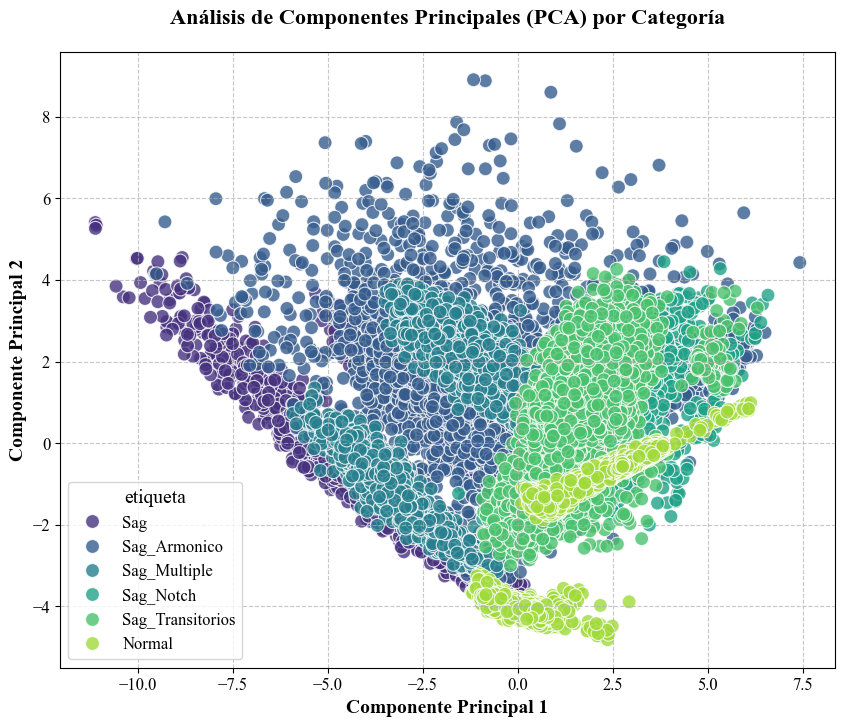

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def graficar_pca(data, features, category_col='etiqueta', output_dir='graficos_analisis'):
    """
    Realiza un análisis de componentes principales (PCA) y grafica los resultados.
    """
    configurar_estilo_academico()

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # 1. Separar características (X) y etiquetas (y)
    X = data[features]
    y = data[category_col]

    # 2. Escalar los datos (muy importante para PCA)
    X_scaled = StandardScaler().fit_transform(X)

    # 3. Aplicar PCA para reducir a 2 componentes
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(X_scaled)
    
    # Crear un DataFrame con los resultados
    df_pca = pd.DataFrame(data=principal_components, columns=['Componente Principal 1', 'Componente Principal 2'])
    df_pca = pd.concat([df_pca, y], axis=1)

    # 4. Graficar
    plt.figure(figsize=(10, 8))
    ax = sns.scatterplot(
        x='Componente Principal 1',
        y='Componente Principal 2',
        hue=category_col,
        data=df_pca,
        palette='viridis',
        s=100, # Tamaño de los puntos
        alpha=0.8
    )

    ax.set_title('Análisis de Componentes Principales (PCA) por Categoría', weight='bold', pad=20)
    ax.set_xlabel('Componente Principal 1', weight='bold')
    ax.set_ylabel('Componente Principal 2', weight='bold')
    ax.grid(linestyle='--', alpha=0.7)
    
    # --- Guardar el Gráfico ---
    nombre_archivo = f"{output_dir}/Analisis_PCA.svg"
    plt.savefig(nombre_archivo, format='svg', transparent=True, bbox_inches='tight')
    print(f"Gráfico guardado en: {nombre_archivo}")
    plt.show()
    plt.close()

# --- Ejemplo de uso ---
if __name__ == '__main__':
    # (Cargas tu DataFrame 'df' y la lista 'features_a_visualizar' como antes)
    graficar_pca(df, features_a_visualizar)

Calculando la matriz de correlación...

¡Éxito! Matriz de correlación guardada como 'graficos_caracteristicas/Mi_Matriz_De_Correlacion.svg'


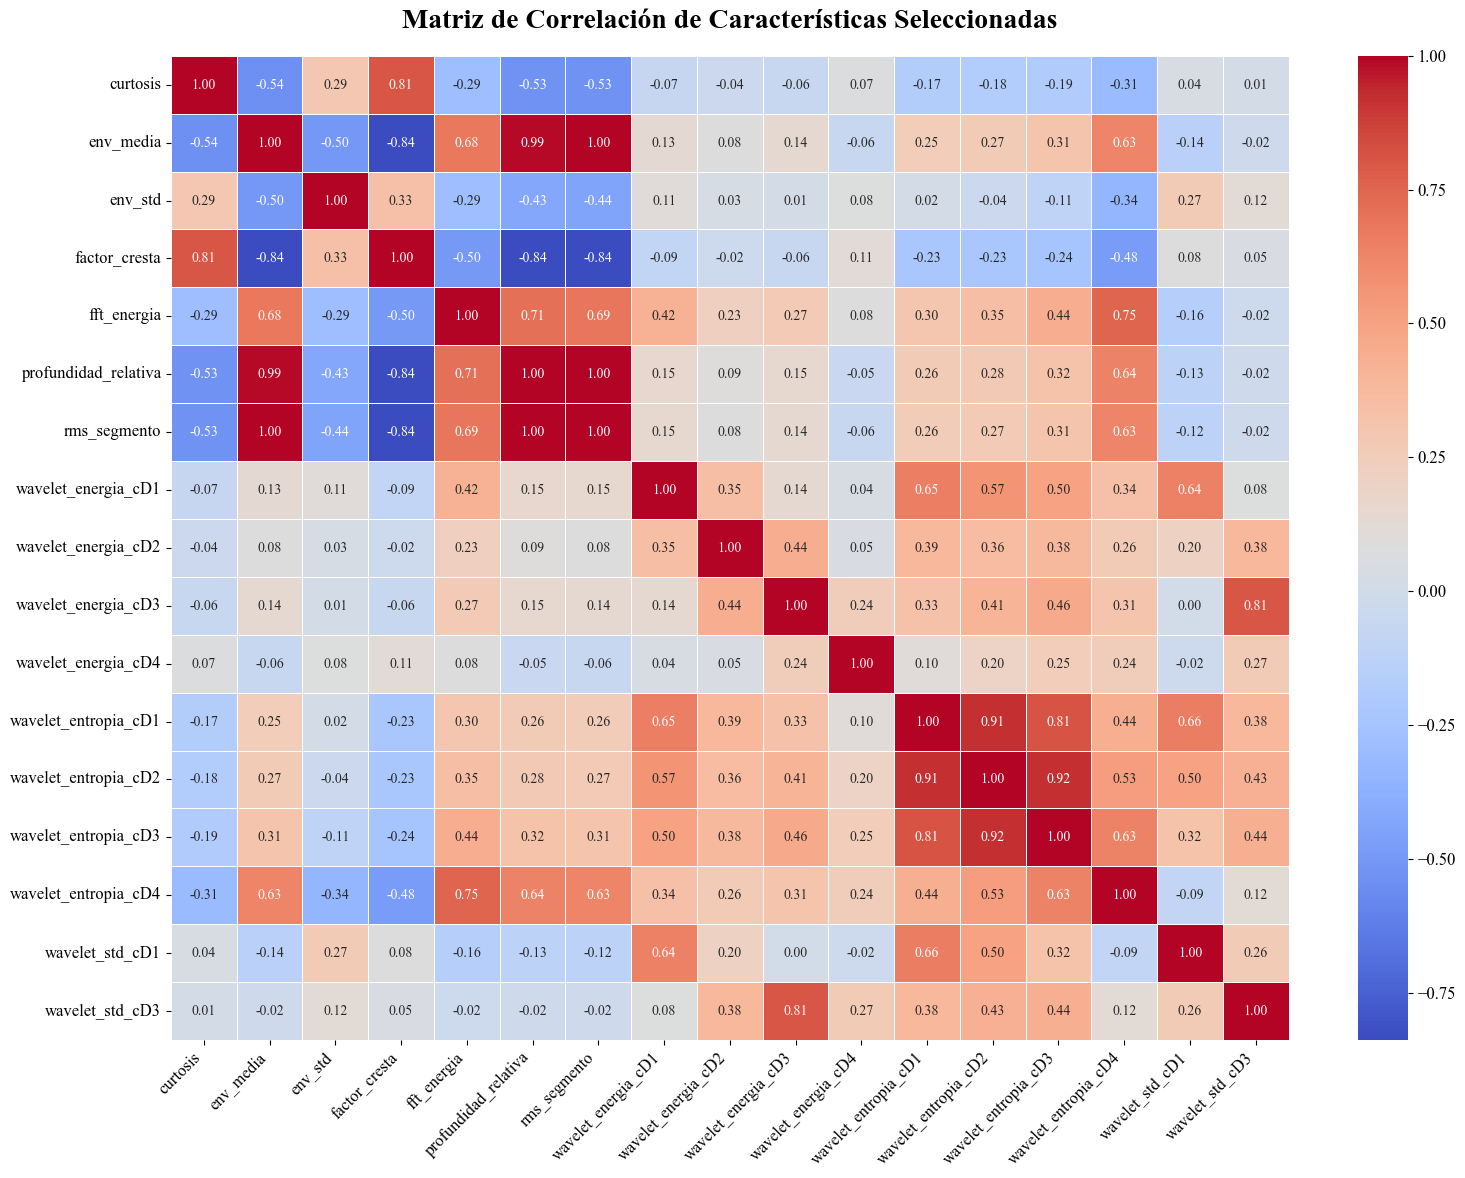

In [5]:
def plot_matriz_correlacion(data: pd.DataFrame, features: list, output_filename: str):
    """
    Calcula, grafica y guarda la matriz de correlación de un conjunto de características.
    """
    # 1. Aplicar el estilo académico
    configurar_estilo_academico()

    # 2. Calcular la matriz de correlación
    print("Calculando la matriz de correlación...")
    # Asegurarse de que solo se usan columnas que existen en el DataFrame
    features_existentes = [col for col in features if col in data.columns]
    if len(features_existentes) != len(features):
        print("Advertencia: Algunas columnas de interés no se encontraron en el DataFrame.")
    
    matriz_corr = data[features_existentes].corr()

    # 3. Crear la figura y el mapa de calor (heatmap)
    plt.figure(figsize=(16, 12))
    ax = sns.heatmap(
        matriz_corr,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        linewidths=.5,
        annot_kws={"size": 10}
    )
    
    # 4. Configurar títulos y etiquetas
    ax.set_title('Matriz de Correlación de Características Seleccionadas', weight='bold', fontsize=20, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    # 5. Guardar la figura
    output_dir = os.path.dirname(output_filename)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        
    plt.savefig(output_filename, format='svg', transparent=True, bbox_inches='tight')
    
    print(f"\n¡Éxito! Matriz de correlación guardada como '{output_filename}'")
    plt.show()


# ==============================================================================
# EJEMPLO DE USO CON TUS CARACTERÍSTICAS
# ==============================================================================
if __name__ == '__main__':
    
    # 1. Define aquí la lista exacta de columnas que te interesan
    lista_features_interes = [
        'curtosis', 'env_media', 'env_std', 'factor_cresta', 'fft_energia',
        'profundidad_relativa', 'rms_segmento', 'wavelet_energia_cD1',
        'wavelet_energia_cD2', 'wavelet_energia_cD3', 'wavelet_energia_cD4',
        'wavelet_entropia_cD1', 'wavelet_entropia_cD2', 'wavelet_entropia_cD3',
        'wavelet_entropia_cD4', 'wavelet_std_cD1', 'wavelet_std_cD3'
    ]

    # 2. Carga tu DataFrame
    # ⚠️ REEMPLAZA ESTA LÍNEA CON LA RUTA A TU ARCHIVO CSV REAL
    try:
        df = pd.read_csv(r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Datos_3\Dataset_Caracteristicas_Final2.csv')
        # Asegurarse de que no hay valores faltantes que puedan causar problemas
        df.dropna(subset=lista_features_interes, inplace=True)
    except FileNotFoundError:
        print("Error: No se encontró 'tu_dataset.csv'. Creando un DataFrame de ejemplo para la demostración.")
        # Crear un DataFrame de ejemplo si el archivo no existe
        df = pd.DataFrame(np.random.rand(100, len(lista_features_interes)), columns=lista_features_interes)
        df['profundidad_relativa'] = df['rms_segmento'] * (1 + np.random.rand(100) * 0.05)


    # 3. Llama a la función para generar y guardar el gráfico
    plot_matriz_correlacion(
        data=df,
        features=lista_features_interes,
        output_filename='graficos_caracteristicas/Mi_Matriz_De_Correlacion.svg'
    )
    

## Generación de Graficas


[(1688, 4494)]
[(0, 8), (1679, 1696), (2760, 2777), (4469, 4486), (7191, 7200)]
[(0, 8), (1679, 4494), (7191, 7200)]
Los intervalos detectados son: Inicio: 1679 Fin: 4494
Los intervalos detectados son: Inicio: 0.23319444444444445 Fin: 0.6241666666666666
Características extraídas del segmento:
rms_segmento: 0.4528
profundidad_relativa: 0.6403
factor_cresta: 2.1381
curtosis: -0.9434
fft_energia: 288.5706
wavelet_energia_cD1: 0.0422
wavelet_entropia_cD1: 1.0678
wavelet_std_cD1: 0.0055
wavelet_energia_cD2: 0.0479
wavelet_entropia_cD2: 2.4282
wavelet_energia_cD3: 0.1013
wavelet_entropia_cD3: 3.2134
wavelet_std_cD3: 0.0168
wavelet_energia_cD4: 0.3136
wavelet_entropia_cD4: 4.1661
env_media: 0.6100
env_std: 0.1946


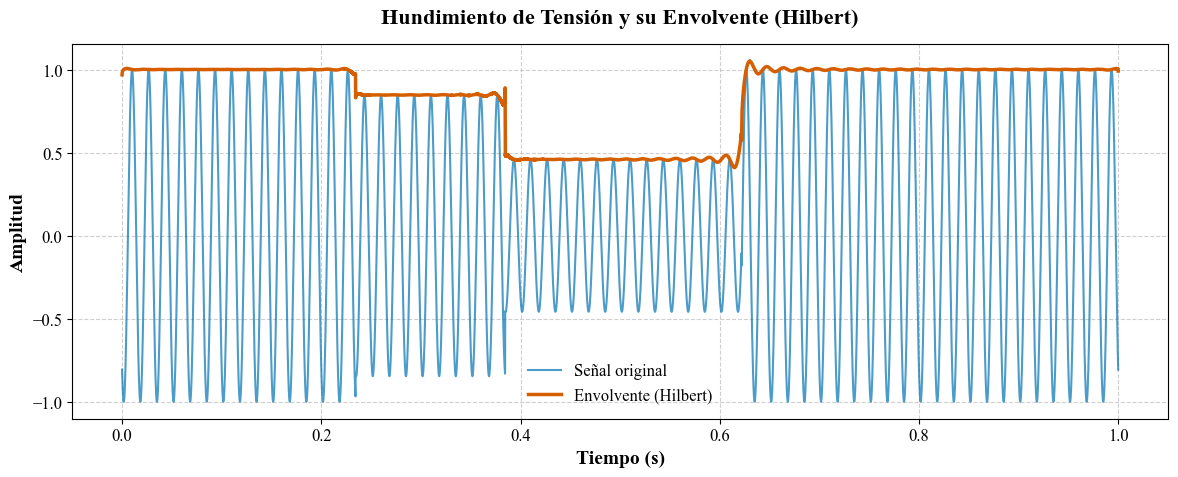

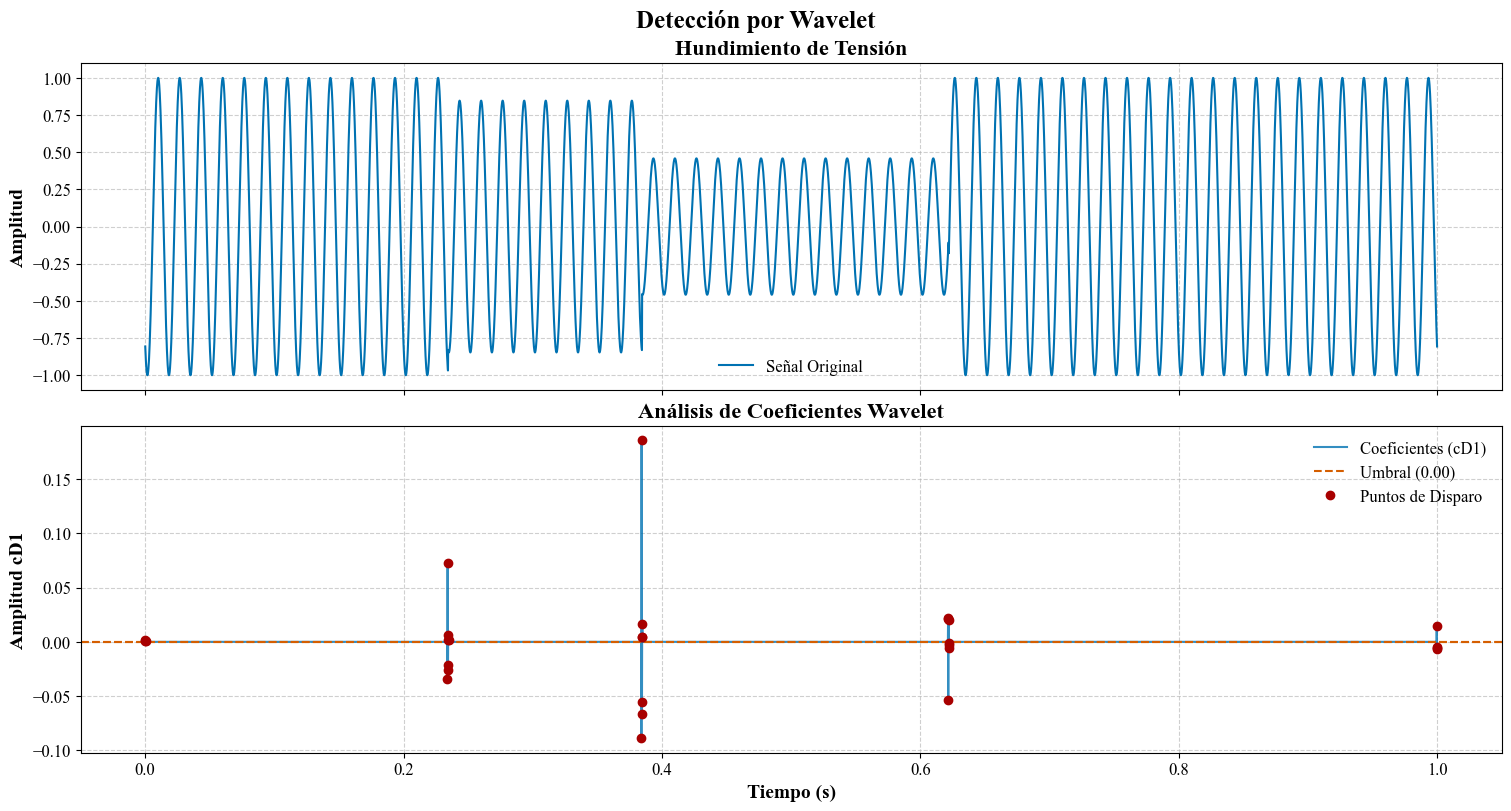

In [31]:
data0 = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Normal\Clase_0_normal.csv'
data1 = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag\Clase_1_sag.csv'
data2 = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Armonic\Clase_2_Armonico.csv'
data3 = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Multiple\Clase_3_sagmultiple.csv'
data4 = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Notch\Clase_4_sagnotch.csv'
data5 = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Transitorios\Clase_5_Transitorios.csv'

data =pd.read_csv(data3)

senal = data['Sag_194'].to_numpy()
#2000 y 2800

intervalos = deteccion(senal, fs=7200)
print("Los intervalos detectados son:" , "Inicio:", intervalos[0][0], "Fin:", intervalos[0][1])
print("Los intervalos detectados son:" , "Inicio:", intervalos[0][0]/7200, "Fin:", intervalos[0][1]/7200)
inicio, fin = intervalos[0] if intervalos else (0, len(senal))
segmento = senal[inicio:fin]
# Extraer características del segmento
caracteristicas = extraer_caracteristicas(segmento, fs=7200, rms_nominal_val=rms_nominal(senal, fs=7200))
print("Características extraídas del segmento:")
for key, value in caracteristicas.items():
    print(f"{key}: {value:.4f}")
envolvente(senal, fs=7200, titulo="Hundimiento de Tensión y su Envolvente (Hilbert)")
wavelet(senal, fs=7200, titulo="Detección por Wavelet")


## Caracteristicas importancia

In [8]:
import pandas as pd
from sklearn.feature_selection import RFE, SelectKBest, f_classif, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# SECCIÓN 1: DEFINICIÓN DE LOS MÉTODOS DE SELECCIÓN (Sin Cambios)
# ==============================================================================
def seleccionar_features_rfe(data, features, category_col, n_features_to_select=10):
    """Método 1: Eliminación Recursiva de Características (RFE)."""
    print("--- Ejecutando Método 1: Eliminación Recursiva (RFE) ---")
    X = data[features]; y = data[category_col]
    model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rfe = RFE(estimator=model, n_features_to_select=n_features_to_select)
    rfe.fit(X, y)
    ranking_df = pd.DataFrame({'Característica': X.columns, 'Ranking RFE': rfe.ranking_}).sort_values(by='Ranking RFE')
    print(f"(El ranking '1' indica las {n_features_to_select} características seleccionadas)")
    print(ranking_df)
    return ranking_df

def seleccionar_features_kbest(data, features, category_col, k=10):
    """Método 2: Prueba Estadística ANOVA F-test."""
    print("\n--- Ejecutando Método 2: Prueba Estadística ANOVA F-test (KBest) ---")
    X = data[features]; y = data[category_col]
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X, y)
    scores_df = pd.DataFrame({'Característica': X.columns, 'Puntuación F (ANOVA)': selector.scores_}).sort_values(by='Puntuación F (ANOVA)', ascending=False)
    print("(Puntuaciones más altas indican características más importantes)")
    print(scores_df)
    return scores_df

# ==============================================================================
# SECCIÓN 2: NUEVA FUNCIÓN DE AYUDA PARA VALIDAR
# ==============================================================================
def validar_columnas(dataframe, lista_features_requeridas, nombre_dataset):
    """
    Verifica si todas las características requeridas existen en el DataFrame.
    Devuelve True si todo está bien, False si faltan columnas.
    """
    columnas_faltantes = set(lista_features_requeridas) - set(dataframe.columns)
    if columnas_faltantes:
        print(f"\n❌ ERROR en {nombre_dataset}: Faltan las siguientes columnas en tu archivo CSV:")
        for col in sorted(list(columnas_faltantes)):
            print(f"  - {col}")
        return False
    return True

# ==============================================================================
# SECCIÓN 3: EJECUCIÓN PRINCIPAL CORREGIDA
# ==============================================================================
if __name__ == '__main__':
    
    caracteristicas_nuevas = [
            'curtosis', 'env_media', 'env_std',
            'factor_cresta', 'fft_energia', 'profundidad_relativa',
            'rms_segmento', 'wavelet_energia_cD1', 'wavelet_energia_cD2','wavelet_energia_cD3', 'wavelet_energia_cD4',
            'wavelet_entropia_cD1', 'wavelet_entropia_cD2', 'wavelet_entropia_cD3', 'wavelet_entropia_cD4',
            'wavelet_std_cD1', 'wavelet_std_cD3'
    ]

    try:
        # --- Carga de los DataFrames ---
        ruta_dataset_v1 = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Datos_3\Dataset_Caracteristicas_Final2.csv'

        
        print(f"Cargando Dataset Antiguo desde: {ruta_dataset_v1}")
        df_v1 = pd.read_csv(ruta_dataset_v1)

        # --- ANÁLISIS DEL DATASET 2 (Características Nuevas) ---
        print("\n\n" + "#"*70)
        print("### ANÁLISIS DEL DATASET CON CARACTERÍSTICAS NUEVAS ###")
        print("#"*70)
        # Se valida antes de ejecutar
        if validar_columnas(df_v1, caracteristicas_nuevas, "Dataset Nuevo"):
            seleccionar_features_rfe(df_v1.dropna(), caracteristicas_nuevas, 'etiqueta')
            seleccionar_features_kbest(df_v1.dropna(), caracteristicas_nuevas, 'etiqueta')

    except FileNotFoundError as e:
        print(f"❌ Error de archivo: No se encontró uno de los archivos. Revisa las rutas. Detalles: {e}")

Cargando Dataset Antiguo desde: C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Datos_3\Dataset_Caracteristicas_Final2.csv


######################################################################
### ANÁLISIS DEL DATASET CON CARACTERÍSTICAS NUEVAS ###
######################################################################
--- Ejecutando Método 1: Eliminación Recursiva (RFE) ---
(El ranking '1' indica las 10 características seleccionadas)
          Característica  Ranking RFE
1              env_media            1
2                env_std            1
5   profundidad_relativa            1
4            fft_energia            1
6           rms_segmento            1
7    wavelet_energia_cD1            1
12  wavelet_entropia_cD2            1
9    wavelet_energia_cD3            1
13  wavelet_entropia_cD3            1
16       wavelet_std_cD3            1
0               curtosis            2
11  wavelet_entropia_cD1            3
15       wavelet_std_cD1            4
3   